### Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
order_level = pd.read_parquet("data/processed/order_level.parquet")

df = order_level[
    (order_level["is_delivered"]) & (~order_level["is_invalid_timestamps"])
].copy()

print(f'Number of orders to analysis: {len(df):,} / {len(order_level):,}')

Number of orders to analysis: 95,103 / 98,666


### Compare reviews between ontime and late delivery

Using Mann-Whitney U because:
* Review scores are not a continuous measurement: The 1–5 star scale is a ranking data (Ordinal), the gap between 1 and 2 stars is not exactly the same as 4 and 5 stars
* Data is strongly skewed (Non-normal distribution): Olist customers mainly give 5 stars, the scores do not follow a standard distribution, so using T-test will cause skewed results.
* Absolutely Safe & Accurate: Mann-Whitney U does not care how skewed the data is, it compares based on ranking order so the results obtained are extremely reputable and objective.

In [10]:
late_group = df[df['is_late']]['review_score'].dropna()
ontime_group = df[~df['is_late']]['review_score'].dropna()

print(f'Average ontime review score: {ontime_group.mean():.2f}')
print(f'Average latetime review score: {late_group.mean():.2f}')

t_stat, p_value = stats.mannwhitneyu(late_group, ontime_group, alternative="less")
print(f"Mann-Whitney U test p-value: {p_value:.6f}")

Average ontime review score: 4.29
Average latetime review score: 2.27
Mann-Whitney U test p-value: 0.000000


#### Insights:
1. Completely reject hypothesis H0​. There is enough statistical evidence to confirm that: Customers who receive late delivery have a significantly lower satisfaction level (review score) than customers who receive goods on time.
2. The difference of up to 2.02 points shows that late delivery is one of the leading causes of poor user experience on Olist, requiring the Logistics department to take measures to improve delivery time or optimize it.

### Delay level vs review score

                    mean  count
delay_bucket                   
Soon/On time    4.289697  88106
Late 1-3 days   3.287731   1842
Late 4-7 days   2.104538   1741
Late 8-14 days  1.672664   1445
Late >14 days   1.722556   1330


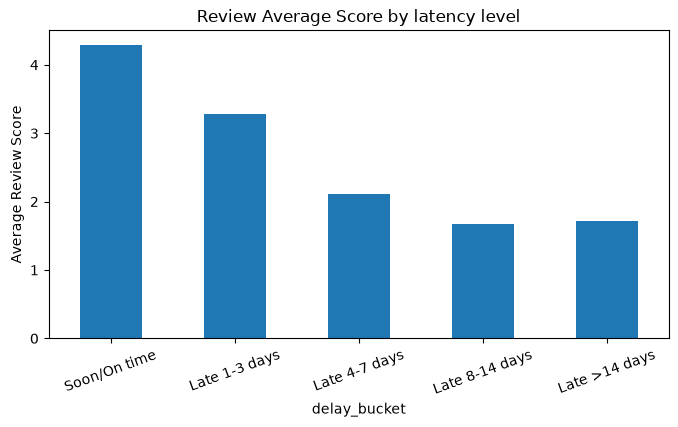

In [14]:
bins = [-np.inf, 0, 3, 7, 14, np.inf]
labels = ["Soon/On time", "Late 1-3 days", "Late 4-7 days", "Late 8-14 days", "Late >14 days"]

df['delay_bucket'] = pd.cut(df['delivery_delay'], bins=bins, labels=labels)

delay_review = df.groupby("delay_bucket", observed=True)["review_score"].agg(["mean", "count"])
print(delay_review)

delay_review["mean"].plot(kind="bar", figsize=(8, 4), title="Review Average Score by latency level")
plt.ylabel("Average Review Score")
plt.xticks(rotation=20)
plt.show()

#### Breaking the announced time hurts more than slow delivery itself
Average review score drops sharply from 4.29 (on-time) to just 1.67–1.72 (delayed more than 8 days) — a decline of over 60%. A Mann-Whitney U test confirms this difference is highly statistically significant (p < 0.001).
The negative effect appears to saturate around the 8-day mark: reviews for "late 8-14 days" (1.67) and "late >14 days" (1.72) are nearly identical, suggesting customers' patience has already "bottomed out" by then — further delay doesn't make the experience meaningfully worse in their eyes.

#### Delivery_time (absolute speed) vs review score, separate from latency

In [15]:
ontime_df = df[~df["is_late"]].copy()

speed_bins = [0, 5, 10, 15, 20, np.inf]
speed_labels = ["<= 5 days", "6-10 days", "11-15 days", "16-20 days", ">20 days"]
ontime_df["speed_bucket"] = pd.cut(ontime_df["delivery_time"], bins=speed_bins, labels=speed_labels)

speed_review = ontime_df.groupby("speed_bucket", observed=True)["review_score"].agg(["mean", "count"])
print(speed_review)

                  mean  count
speed_bucket                 
<= 5 days     4.433752  18612
6-10 days     4.351769  31930
11-15 days    4.261532  20594
16-20 days    4.138287  10160
>20 days      3.915723   6799


#### Delivery speed also matters, but not as meeting the promised date
Among on-time orders only, review scores decline more gradually as delivery_time increases — from 4.43 (<=5 days) to 3.92 (>20 days), a drop of about 0.5 points. This is much milder than the ~2.6-point drop caused by lateness. This points to a key behavioral pattern: customers tolerate a long wait if it was promised upfront, but react strongly when an expectation is broken — expectation violation matters more than absolute speed.

#### Analysis by state

In [16]:
late_by_state = (
    df.groupby("customer_state")
    .agg(
        n_orders=("order_id", "count"),
        late_rate=("is_late", "mean"),
        avg_review=("review_score", "mean"),
    )
    .query("n_orders >= 30")  # Remove states which have too less orders
    .sort_values("late_rate", ascending=False)
)
print(late_by_state)

                n_orders  late_rate  avg_review
customer_state                                 
AL                   393   0.211196    3.866667
MA                   705   0.177305    3.835714
SE                   333   0.153153    3.906627
PI                   469   0.140725    4.002155
CE                  1260   0.139683    3.943381
RR                    40   0.125000    3.875000
RJ                 12215   0.122145    3.962325
BA                  3210   0.121807    3.927427
PA                   936   0.111111    3.913326
ES                  1968   0.108232    4.078270
PB                   509   0.104126    4.073413
TO                   270   0.100000    4.144981
MS                   696   0.097701    4.158501
PE                  1573   0.097266    4.076331
RN                   467   0.094218    4.152688
SC                  3493   0.083309    4.128679
GO                  1921   0.065591    4.101571
RS                  5262   0.061764    4.183448
MT                   871   0.060850    4

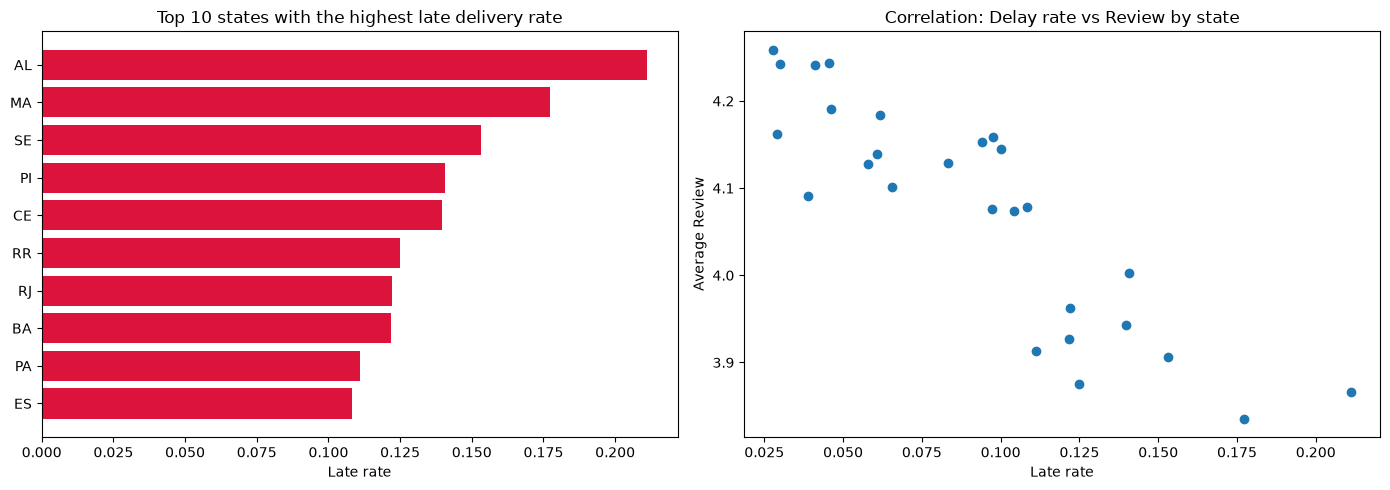

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top10_late = late_by_state.head(10)
axes[0].barh(top10_late.index, top10_late["late_rate"], color="crimson")
axes[0].invert_yaxis()
axes[0].set_title("Top 10 states with the highest late delivery rate")
axes[0].set_xlabel("Late rate")

axes[1].scatter(late_by_state["late_rate"], late_by_state["avg_review"])
axes[1].set_xlabel("Late rate")
axes[1].set_ylabel("Average Review")
axes[1].set_title("Correlation: Delay rate vs Review by state")

plt.tight_layout()
plt.show()

In [21]:
print(late_by_state[["late_rate", "avg_review"]].corr())

            late_rate  avg_review
late_rate    1.000000   -0.876425
avg_review  -0.876425    1.000000


#### Delay rates vary sharply by state, and strongly correlate with lower reviews.
The correlation between state-level late delivery rate and average review score is -0.876 — a very strong negative relationship. States with the highest late rates — Alagoas (AL, 21.1%), Maranhao~ (MA, 17.7%), and Sergipe (SE, 15.3%) — are concentrated in Brazil's Northeast region, farther from the country's main distribution hubs in the Southeast. These states also show among the lowest average review scores in the dataset. A few low-volume northern states (AM, AP, RO) show low late rates, but with order counts as small as 67–144, these figures are less reliable and shouldn't be over-interpreted.

#### Recommended actions (in priority order)
**1. Improve estimated delivery date accuracy:** — since breaking the delivery promise is far more damaging than slow-but-honest delivery, tightening or better calibrating the estimation model (especially for high-risk regions) should be the top priority.

**2. Invest in regional logistics for the Northeast cluster:** (AL, MA, SE, PI, CE) — these states show both the highest late rates and correspondingly low review scores, making them the clearest candidates for dedicated warehousing or local carrier partnerships.

**3. Treat the 7–8 day delay threshold as an early-warning KPI:** — orders crossing this point should trigger proactive intervention (customer notification, compensation) before a review is ever submitted.